# Pleasant Weather Outlook
DPT - Dewpoint
TCDC - Total Cloud Cover
TMP - Temperature
WIND - Windspeed

In [2]:
import matplotlib.pyplot as plt
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.dates as mdates

In [3]:
run = pd.Timestamp("2025-4-29-12")

In [4]:
H = FastHerbie([run], model="nam", product="conusnest.hiresf", fxx=np.arange(0,61,3).tolist(), save_dir='./data/', overwrite=True)

In [5]:
ss2 = '((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))'
ss2 = H.xarray(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from com

In [6]:
ss2[1]['wsp'] = np.sqrt(ss2[1]['u10']**2+ss2[1]['v10']**2) 
ss2[1]['tcc'] = ss2[0]['tcc']
ss2[1]['t2m'] = ss2[2]['t2m']
ss2[1]['d2m'] = ss2[2]['d2m']
ds = ss2[1]
ds = ds.drop_vars('u10')
ds = ds.drop_vars('v10')
ds['t2m_F'] = (ds['t2m'] - 273.15) * 9/5 + 32
ds['d2m_F'] = (ds['d2m'] - 273.15) * 9/5 + 32

ds['wsp'] = ds['wsp'] * 2.23693629
ds

<xarray.Dataset> Size: 991MB
Dimensions:                (step: 21, y: 1059, x: 1799)
Coordinates:
  * step                   (step) timedelta64[ns] 168B 00:00:00 ... 2 days 12...
    time                   datetime64[ns] 8B 2025-04-29T12:00:00
    heightAboveGround      float64 8B 10.0
    latitude               (y, x) float64 15MB 21.14 21.14 21.15 ... 47.85 47.84
    longitude              (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time             (step) datetime64[ns] 168B 2025-04-29T12:00:00 ......
    gribfile_projection    object 8B None
    atmosphereSingleLayer  float64 8B 0.0
Dimensions without coordinates: y, x
Data variables:
    wsp                    (step, y, x) float32 160MB 17.85 17.89 ... 17.9 18.06
    tcc                    (step, y, x) float32 160MB 96.0 98.0 99.0 ... 0.0 0.0
    t2m                    (step, y, x) float32 160MB 291.4 291.4 ... 274.6
    d2m                    (step, y, x) float32 160MB 288.0 288.0 ... 272.5
    t2m_F                  (step, y, x) float32 160MB 64.94 64.92 ... 34.63
    d2m_F                  (step, y, x) float32 160MB 58.68 58.66 ... 30.92 30.9
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   nam
    product:                 conusnest.hiresf
    description:             North America Mesoscale - CONUS
    search:                  ((UGRD|VGRD):(10 m ))|(TCDC)|((TMP|DPT):(2 m ))

In [7]:
def GeoAxes():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())
    ax.add_feature(cfeature.COASTLINE, linewidth=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.5)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':',linewidth=1)
    ax.set_extent([-120, -73, 23, 50])
    return fig,ax

In [8]:
init_time = ds['valid_time'].values[0]
init_time = pd.to_datetime(init_time)
init_time = init_time.strftime('%HZ %a %b %d %Y')
print(init_time)

12Z Tue Apr 29 2025


In [9]:
run = 5
valid_time = ds['valid_time'].values[run]
valid_time = pd.to_datetime(valid_time)
valid_time = valid_time.strftime('%HZ %a %b %d %Y')
print(valid_time)

03Z Wed Apr 30 2025


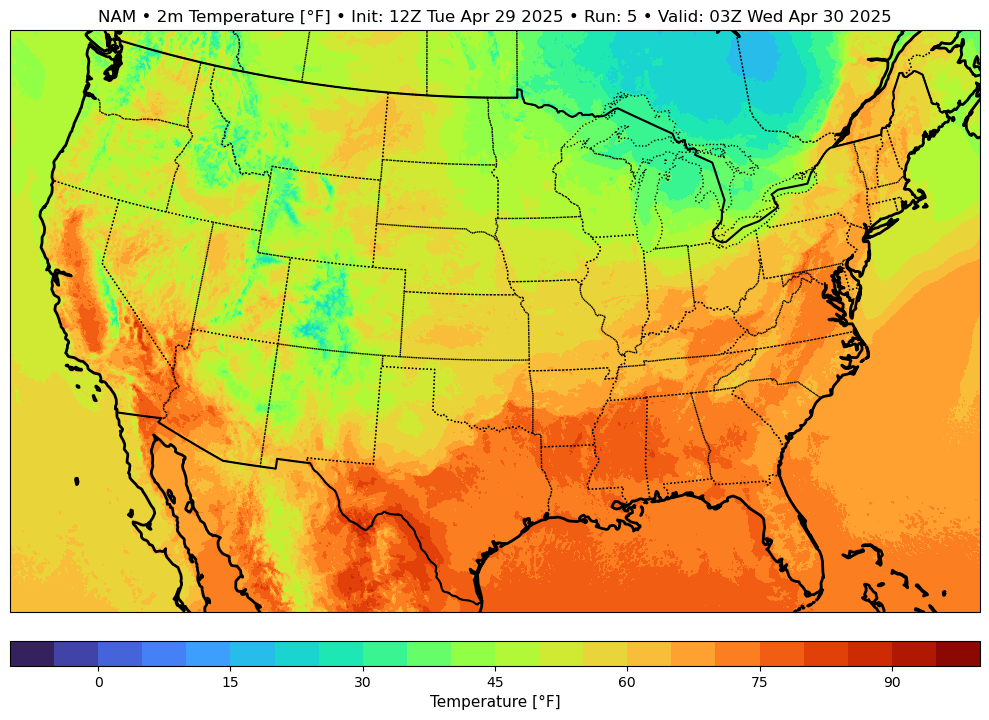

In [10]:
fig, ax = GeoAxes()
dataproj = ccrs.PlateCarree()
mapproj = ccrs.LambertConformal()
ds_sub = ds.isel(y = slice(30, 1050), x = slice(90, 1760))
lat = ds_sub.latitude
lon = ds_sub.longitude
levels = np.arange(-10,101,5)
cs = ax.contourf(lon, lat, ds_sub['t2m_F'].values[run], cmap='turbo', vmin=-10,vmax = 100,levels=levels,transform=dataproj, transform_first = True)
plt.title(f"NAM \u2022 2m Temperature [°F] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Temperature [°F]", fontsize=11)
plt.tight_layout()
plt.show()

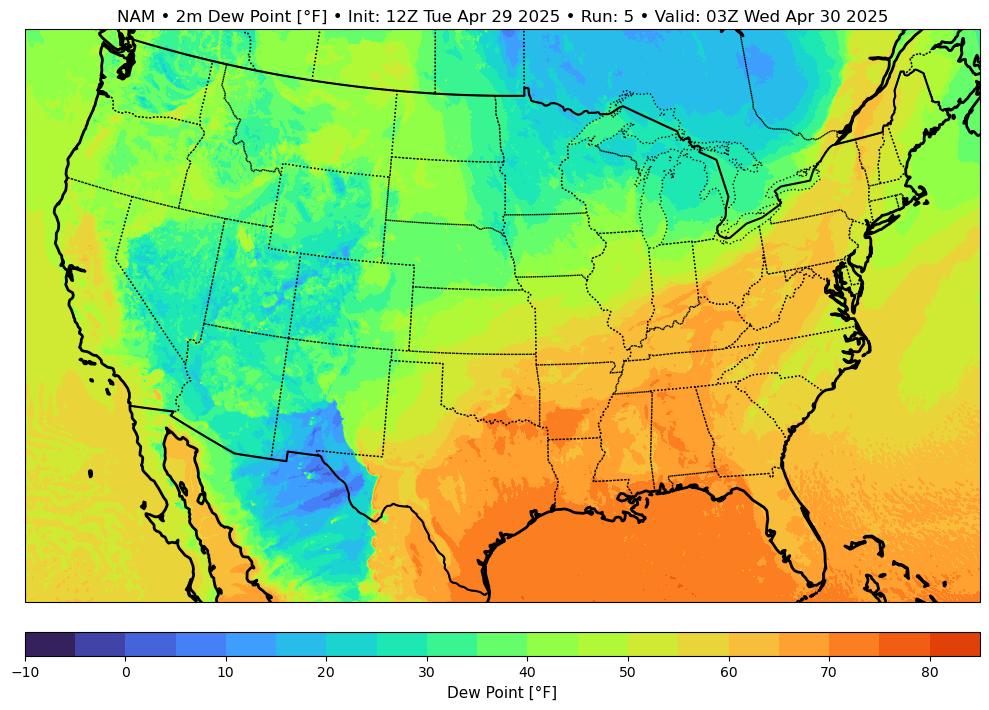

In [11]:
fig, ax = GeoAxes()
levels = np.arange(-10,90,5)
cs = ax.contourf(lon, lat, ds_sub['d2m_F'].values[run], cmap='turbo', vmin=-10,vmax = 100,levels=levels,transform=dataproj, transform_first = True)
plt.title(f"NAM \u2022 2m Dew Point [°F] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Dew Point [°F]", fontsize=11)
plt.tight_layout()
plt.show()

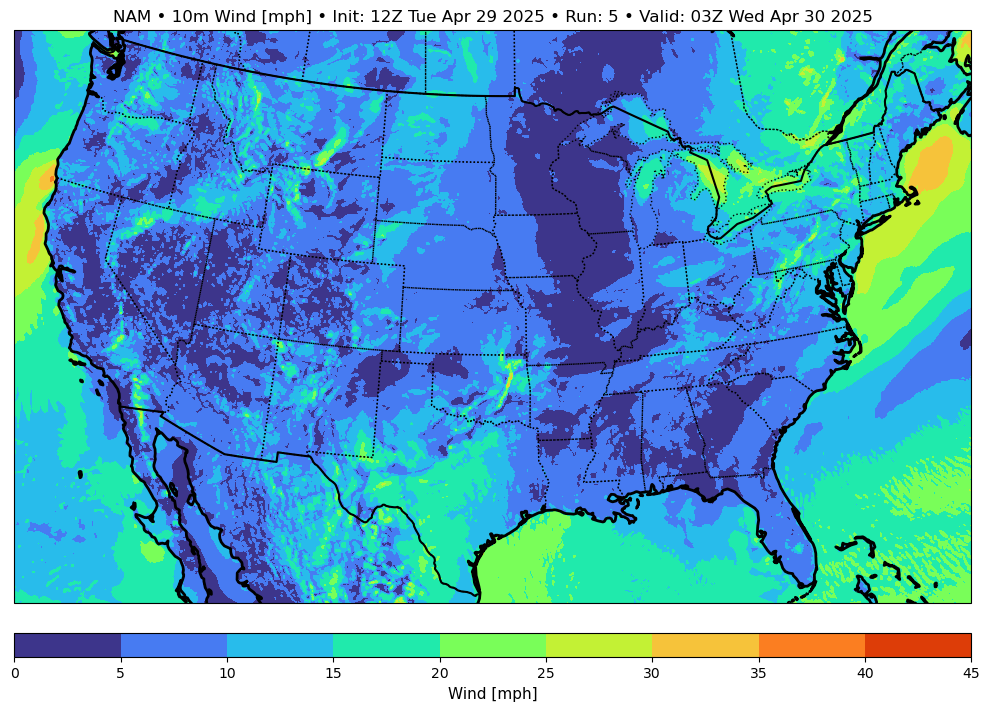

In [12]:
fig, ax = GeoAxes()
levels = np.arange(0,50,5)
cs = ax.contourf(lon, lat, ds_sub['wsp'].values[run], cmap='turbo', vmin=0,vmax = 50,levels=levels,transform=dataproj,transform_first = True)
plt.title(f"NAM \u2022 10m Wind [mph] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Wind [mph]", fontsize=11)
plt.tight_layout()
plt.show()

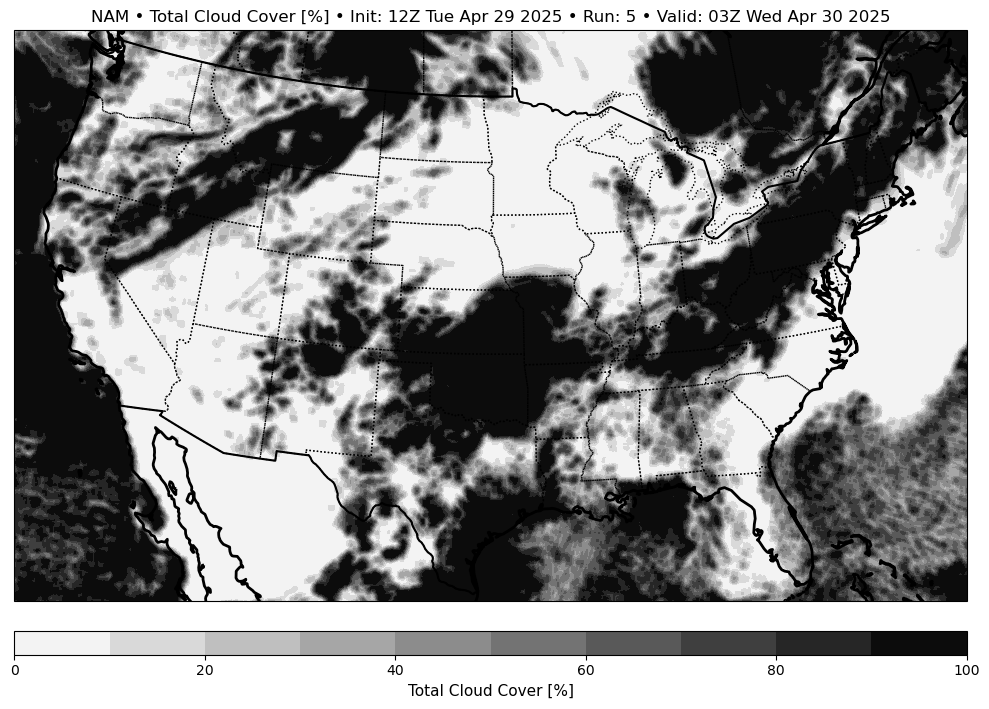

In [13]:
fig, ax = GeoAxes()
levels = np.arange(0,101,10.)
# cs = ax.contourf(lon, lat, ds_sub['tcc'].values[run], cmap='binary', vmin=0,vmax = 100,levels=levels,transform=dataproj)
# cs = ax.pcolormesh(lon, lat, ds_sub.isel(step = run).tcc, cmap = 'binary_r', vmin = 0, vmax = 100, transform=dataproj)
cs = ax.contourf(lon, lat, ds_sub['tcc'].values[run], cmap = 'binary', vmin=0, vmax = 100, levels=levels, transform=dataproj, transform_first = True) #LJL - transform_first = True solves plotting issue

plt.title(f"NAM \u2022 Total Cloud Cover [%] \u2022 Init: {init_time} \u2022 Run: {run} \u2022 Valid: {valid_time}")
cbar = plt.colorbar(cs,ax=ax,orientation="horizontal",pad=0.04,fraction=0.05,aspect=40)
cbar.set_label("Total Cloud Cover [%]", fontsize=11)
plt.tight_layout()
plt.show()

In [56]:
np.unique(ds_sub['tcc'].values[run])

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100.], dtype=float32)

In [ ]:
plt.contourf(lon, lat,ds_sub['tcc'].values[run], cmap='binary_r', vmin=0,vmax = 100,levels=levels)
# dataproj

In [ ]:
plt.pcolormesh(lon, lat, ds_sub.isel(step = run).tcc.values)

In [ ]:
ds_sub['tcc'].values